### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx


# **Ejemplo 00: OLS -Precios de Cierre de Google**

Definimos el vector (np.array) 'price' que corresponde al precio de cierre de las acciones de Google, son el promedio mensual durante un año (08/2024-08/2025).

Los datos los conseguimos de [Investing.com](https://mx.investing.com/equities/google-inc-historical-data).


In [ ]:
import numpy as np

price=np.array([163.38, 165.85,171.11,168.95,189.30,204.02,170.28,158.80,171.74,176.23,191.90,212.91])
days=np.array([1,2,3,4,5,6,7,8,9,10,11,12])

Enseguida graficamos los datos anteriores.

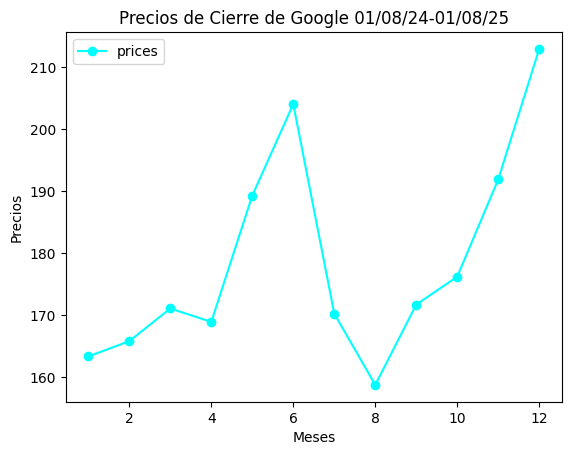

In [ ]:
import matplotlib.pyplot as plt  # la libreria/paquete 'matplotlib' es para graficar

plt.plot(days,price, color='cyan',marker='o', linestyle='-',label='prices')
plt.xlabel('Meses')
plt.ylabel('Precios')
plt.title('Precios de Cierre de Google 01/08/24-01/08/25')
plt.legend()

plt.show()

### **Diagrama de dispersión**

Aquí presentamos los datos observados (dias,precio) como puntos en el plano.

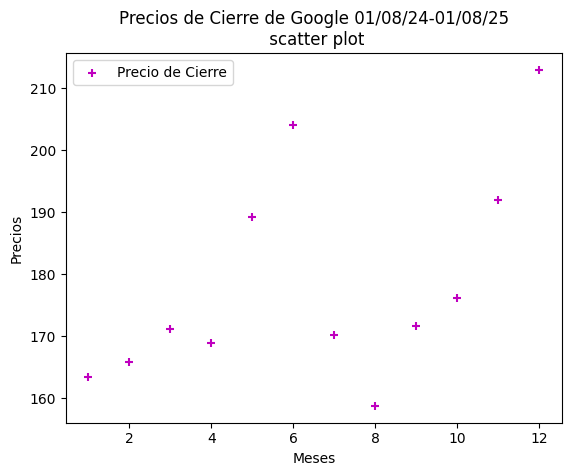

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(days,price,  color='m', marker='+',label='Precio de Cierre')
plt.xlabel('Meses')
plt.ylabel('Precios')
plt.title('Precios de Cierre de Google 01/08/24-01/08/25\n scatter plot')
plt.legend()

plt.show()

In [ ]:
import statsmodels.api as sm

x = sm.add_constant(days)
y = price
result = sm.OLS(y, x).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     3.756
Date:                Wed, 04 Feb 2026   Prob (F-statistic):             0.0814
Time:                        03:27:26   Log-Likelihood:                -48.577
No. Observations:                  12   AIC:                             101.2
Df Residuals:                      10   BIC:                             102.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        162.7097      9.346     17.410      0.0

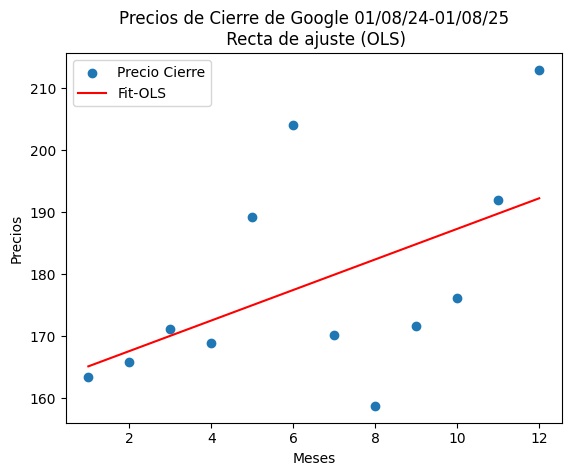

In [ ]:
predicted_prices = result.predict(x)
plt.scatter(days, y, label='Precio Cierre')
plt.plot(days, predicted_prices, color='red', label='Fit-OLS')
plt.xlabel('Meses')
plt.ylabel('Precios')
plt.title('Precios de Cierre de Google 01/08/24-01/08/25\n Recta de ajuste (OLS)')
plt.legend()

plt.show()

# **Método de mínimos cuadrados ordinarios (Ordinary least square OLS)**

En esta primer unidad, vamos a estudiar y análizar el método de OLS. Este es de los métodos estadísticos básicos utilizados en el análisis de datos económicos, marca el inicio entre los "muchos" métodos utilizados para el Análisis de Datos. Nuestro objetivo es aprender los fundamentos y los supuestos para la implementación de OLS, y ser cautelosos en la interpretación de los resultados obtenidos.

Paul Samuelson nos advierte:



> "Algunos de nuestros mejores **economistas parecen ser bastante malos pronosticadores** del futuro.
De hecho, uno de nuestros mejores economistas ni siquiera pudo prever correctamente los resultados de las últimas elecciones. ¿Es legítimo preguntarle a un académico: "Si eres tan científico y erudito, ¿cómo es que eres tan estúpido prediciendo el PNB del año que viene?".

> Creo que no, y por varias razones. En primer lugar, alguien puede ser un matemático brillante en el diseño de métodos para uso de los físicos y aun así ser un físico muy malo. O puede ser un genio en el diseño de métodos estadísticos y aun así ser bastante malo en la realización de investigaciones estadísticas. Supongamos, entonces, que una persona puede ser mala en cualquier predicción dentro de un campo y aun así ser un ciudadano útil. Solo entonces lo llamaríamos "matemático" en lugar de simplemente físico, estadístico o economista.
> Sir Ronald Fisher, por ejemplo, a quien todos lo reconocemos con gusto, ¡fue un genio!. Y quizás realizó un buen trabajo empírico en el campo de la agronomía y la aplicación de fertilizantes. Pero debo decir que su trabajo sobre genética --en el que deduce alegremente la decadencia de la civilización romana y de todas las civilizaciones a partir de la cobarde costumbre que tenían las herederas infértiles de arrebatar a los jóvenes más capaces para casarse, volviéndolos así infértiles-- me parece una inferencia estadística terriblemente superficial. Y no puedo creer que Fisher se cubriera de gloria inmortal al final de su vida, cuando dudo  que fumar e inhalar cigarrillos tuviera algo que ver con la reducción de la longevidad." [Samuelson (1967)](https://alumnosuacj-my.sharepoint.com/:b:/g/personal/ralmanza_uacj_mx/EbE4PmrhhmdDviJPhdlKpYABmyBEjz_YHbn99Aw9MEt5yQ?e=ezd3mm)




# **Ejemplo 00: Precios cierre de Google (visualizando datos como debe ser)**

Vamos a repetir el ejemplo anterior, haciendolo de la forma eficiente (pa'eso es python 🥰)

**Cuando ya tenemos un archivo "CSV"**

1. Hay que subirlo a *Google Drive* (se recomienda crear una carpeta para los datos) y montarlo en el *NoteBook* con el siguiente código

```python
from google.colab import drive

drive.mount('/content/drive')
```

Esta instrucción abre una ventana de autentificación que debemos aceptar. Aquí le estamos dando permiso a Google que entre a nuestro Drive (para entrar a las diversas carpetas -nos interesa ver los datos-).

2. Posteriormente, en el panel izquierdo hay una carpeta y ahí buscamos el archivo de interés, lo seleccionamos y seleccionando el archivo.CSV y le damos click a los 3puntos para copiar el path del archivo. Posteriormente agregamos el siguiente código para leer el archivo.CSV

```python
import pandas as pd

path='path'
df_bonus=pd.read_csv('path')
```
La instrucción anterior es para que ```Colab```tenga acceso a la base de datos, ahora solo queda leer el file.CSV desde nuestro notebook.

3. Definimos un nombre para la 'base de datos' con el que vamos a trabajar, esto es posible con la libreria ```import pandas as pd```
y el siguiente código

```python
Data_nombre=pd.read_csv('path')
Data_nombre.head()
```
La función ```.head()```nos permite visualizar las cinco primeras observaciones del archivo CSV.







In [ ]:
#       1.
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#       2.
import pandas as pd

path="/content/drive/MyDrive/Colab Notebooks/DataSets/google.csv"
df_bonus = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/google.csv")


In [ ]:
#       3.
Data_Google=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/google.csv")
Data_Google


,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
0,01.11.2025,299.74,282.15,306.40,271.04,601.80M,6.60%
1,01.10.2025,281.19,240.75,291.59,235.84,729.58M,15.67%
2,01.09.2025,243.10,208.44,256.00,206.20,829.47M,14.18%
3,01.08.2025,212.91,189.02,214.65,187.82,617.60M,10.95%
4,01.07.2025,191.90,175.74,197.95,172.77,860.11M,8.89%
5,01.06.2025,176.23,167.84,181.23,162.00,847.45M,2.61%
6,01.05.2025,171.74,160.45,176.77,147.84,942.81M,8.15%
7,01.04.2025,158.80,153.62,166.10,140.53,842.65M,2.69%
8,01.03.2025,154.64,171.93,174.97,150.66,732.19M,-9.18%
9,01.02.2025,170.28,200.69,207.05,166.77,629.46M,-16.54%


### **Observemos que:** el primer elemento de la base de datos es la última observación realizada en el cierre del precio. Preferimos mostrar los datos en orden inverso, es decir, que la primer observación sea la de la fecha 01/09/2023 y la última sea la de la fecha 01/08/2025. Esto se realiza invirtiendo la base de datos con la función ```.iloc[::-1]```, posteriormente, redefinimos el index con  ```.reset_index(drop=True)``` como se muestra enseguida.



In [ ]:
Data_Google = Data_Google.iloc[::-1]
Data_Google

,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
24,01.11.2023,132.53,124.07,139.42,123.71,535.34M,6.81%
23,01.12.2023,139.69,131.86,142.68,127.90,620.00M,5.40%
22,01.01.2024,140.10,138.55,153.78,135.15,581.87M,0.29%
21,01.02.2024,138.46,142.12,149.44,135.41,647.51M,-1.17%
20,01.03.2024,150.93,138.43,152.26,130.66,672.72M,9.01%
19,01.04.2024,162.78,150.69,174.71,149.60,659.88M,7.85%
18,01.05.2024,172.50,164.30,178.77,163.05,542.41M,5.97%
17,01.06.2024,182.15,172.54,186.05,171.16,461.09M,5.59%
16,01.07.2024,171.54,183.03,191.75,164.06,526.15M,-5.82%
15,01.08.2024,163.38,170.25,174.05,154.93,550.74M,-4.76%


In [ ]:
Data_Google['Cierre'][2]

np.float64(243.1)

# **.reset_index(drop=True)**

Ahora redefinimos el index con la función ```.reset_index(drop=True)```



In [ ]:
Data_Google=Data_Google.reset_index(drop=True)
Data_Google

,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
0,01.11.2023,132.53,124.07,139.42,123.71,535.34M,6.81%
1,01.12.2023,139.69,131.86,142.68,127.90,620.00M,5.40%
2,01.01.2024,140.10,138.55,153.78,135.15,581.87M,0.29%
3,01.02.2024,138.46,142.12,149.44,135.41,647.51M,-1.17%
4,01.03.2024,150.93,138.43,152.26,130.66,672.72M,9.01%
5,01.04.2024,162.78,150.69,174.71,149.60,659.88M,7.85%
6,01.05.2024,172.50,164.30,178.77,163.05,542.41M,5.97%
7,01.06.2024,182.15,172.54,186.05,171.16,461.09M,5.59%
8,01.07.2024,171.54,183.03,191.75,164.06,526.15M,-5.82%
9,01.08.2024,163.38,170.25,174.05,154.93,550.74M,-4.76%


In [ ]:
Data_Google['Cierre'][2]

np.float64(140.1)

# **Gráficas con matplotlib.pyplot**

La columna 'Fecha' esta en formato de "tiempo"; sin embargo, para que python lo reconozca, es necesario declararlo (especificar) que ese es el formato con la función ```.to_datetime()```. Posteriormente, realizamos la gráfica.

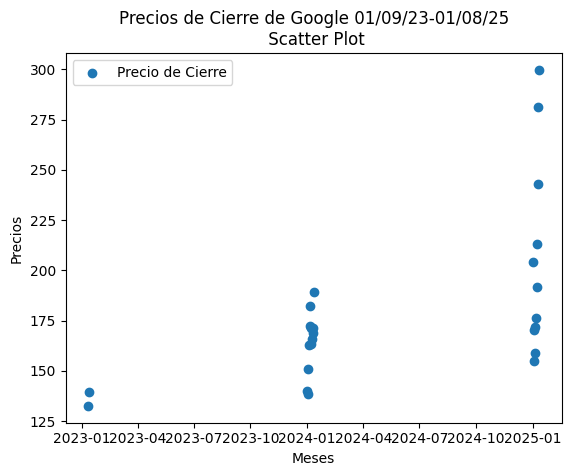

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

x = pd.to_datetime(Data_Google['Fecha']) # Convert 'Fecha' to datetime objects
y = Data_Google['Cierre'] # Select the 'Cierre' column as a Series
plt.scatter(x, y, label='Precio de Cierre') # Changed to scatter plot

plt.xlabel('Meses')
plt.ylabel('Precios')
plt.title('Precios de Cierre de Google 01/09/23-01/08/25\n Scatter Plot') # Updated title
plt.legend()

plt.show()


In [ ]:
from datetime import datetime
import pandas as pd

Data_Google['Fecha'] = pd.to_datetime(Data_Google['Fecha'], format='mixed', dayfirst=True)
Data_Google['Fecha'] = Data_Google['Fecha'].dt.strftime("%d/%m/%Y")
Data_Google

,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
0,01/11/2023,132.53,124.07,139.42,123.71,535.34M,6.81%
1,01/12/2023,139.69,131.86,142.68,127.90,620.00M,5.40%
2,01/01/2024,140.10,138.55,153.78,135.15,581.87M,0.29%
3,01/02/2024,138.46,142.12,149.44,135.41,647.51M,-1.17%
4,01/03/2024,150.93,138.43,152.26,130.66,672.72M,9.01%
5,01/04/2024,162.78,150.69,174.71,149.60,659.88M,7.85%
6,01/05/2024,172.50,164.30,178.77,163.05,542.41M,5.97%
7,01/06/2024,182.15,172.54,186.05,171.16,461.09M,5.59%
8,01/07/2024,171.54,183.03,191.75,164.06,526.15M,-5.82%
9,01/08/2024,163.38,170.25,174.05,154.93,550.74M,-4.76%


## **Eliminar observaciones de la Base de Datos**

La idea es repetir las gráficas iniciales y la base de datos 'N_Google' tiene observaciones que van desde 01/09/2023 y solo nos interesan las observaciones del 01/08/2024 al 01/08/2025. Por lo tanto, vamos a eliminar las observaciones que no necesitamos (las primeras 11).

* ```N_Google.tail(-11)```
* ```N_Google.drop(index=range(11))```
* ```N_Google.iloc[11:]```



In [ ]:
N_Google=Data_Google.iloc[12:]
N_Google

,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
12,01/11/2024,168.95,170.07,182.49,163.70,529.99M,-1.26%
13,01/12/2024,189.30,168.76,201.42,168.57,645.62M,12.04%
14,01/01/2025,204.02,190.65,205.48,187.36,500.38M,7.78%
15,01/02/2025,170.28,200.69,207.05,166.77,629.46M,-16.54%
16,01/03/2025,154.64,171.93,174.97,150.66,732.19M,-9.18%
17,01/04/2025,158.80,153.62,166.10,140.53,842.65M,2.69%
18,01/05/2025,171.74,160.45,176.77,147.84,942.81M,8.15%
19,01/06/2025,176.23,167.84,181.23,162.00,847.45M,2.61%
20,01/07/2025,191.90,175.74,197.95,172.77,860.11M,8.89%
21,01/08/2025,212.91,189.02,214.65,187.82,617.60M,10.95%


# **.rename(columns={'Actual':'Nuevo'})**

Solo queda cambiar nombre de la columna (variable) y volver a redefinir el index, el index ya lo habíamos hecho con ```.reset_index(drop=True)``` y para cambiar nombre utilizamos ```.rename(columns={'Actual':'Nuevo'})```

In [ ]:
N_Google=N_Google.rename(columns={'Cierre':'Precio'})
N_Google
N_Google=N_Google.reset_index(drop=True)
N_Google

,Fecha,Precio,Apertura,Máximo,Mínimo,Vol.,% var.
0,01/11/2024,168.95,170.07,182.49,163.70,529.99M,-1.26%
1,01/12/2024,189.30,168.76,201.42,168.57,645.62M,12.04%
2,01/01/2025,204.02,190.65,205.48,187.36,500.38M,7.78%
3,01/02/2025,170.28,200.69,207.05,166.77,629.46M,-16.54%
4,01/03/2025,154.64,171.93,174.97,150.66,732.19M,-9.18%
5,01/04/2025,158.80,153.62,166.10,140.53,842.65M,2.69%
6,01/05/2025,171.74,160.45,176.77,147.84,942.81M,8.15%
7,01/06/2025,176.23,167.84,181.23,162.00,847.45M,2.61%
8,01/07/2025,191.90,175.74,197.95,172.77,860.11M,8.89%
9,01/08/2025,212.91,189.02,214.65,187.82,617.60M,10.95%


# **Gráfica de variables seleccionadas de un DataFrame**

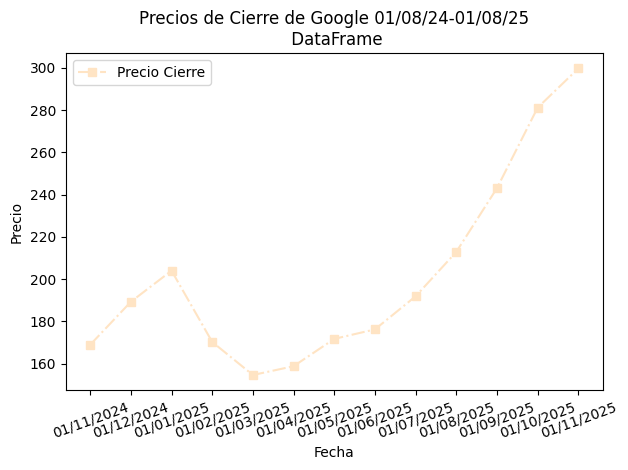

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

x = N_Google['Fecha']
y = N_Google['Precio']
plt.plot(x, y, color='bisque',marker='s', linestyle='-.',label='Precio Cierre')

plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title('Precios de Cierre de Google 01/08/24-01/08/25\n DataFrame')
plt.xticks(rotation=20) # rotacion del label_x: fecha
plt.tight_layout() # evita el  overlapping del label

plt.legend()

plt.show()

In [ ]:
len(N_Google)

16

###  **La variable 'Fecha'**

La variable 'Fecha' es una variable de 'date' por esa razon no python no hace la regresión lineal :-(

In [ ]:
import statsmodels.api as sm

x = N_Google['Fecha'] # Independent variable
y = N_Google['Precio'] # Dependent variable
#   REALIZA LA REGRESION LINEAL
model = sm.OLS(y, x).fit()
#   MUESTRA LOS RESULTADOS DE OLS
model.summary()

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

# **Código de OLS**

Así se realizamos los MCO/OLS

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Ensure 'month_num' column exists (create if not already created)
if 'DATE' not in N_Google.columns:
    N_Google['DATE'] = range(1, len(N_Google) + 1)

X = sm.add_constant(N_Google['DATE']) # Add a constant (intercept) to the independent variable
y = N_Google['Precio'] # Dependent variable

#   REALIZA LA REGRESION LINEAL
model = sm.OLS(y, X).fit()
#   MUESTRA LOS RESULTADOS DE OLS
model.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Precio   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     14.09
Date:                Wed, 04 Feb 2026   Prob (F-statistic):            0.00319
Time:                        04:48:50   Log-Likelihood:                -62.413
No. Observations:                  13   AIC:                             128.8
Df Residuals:                      11   BIC:                             130.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        139.4327     18.824      7.407      0.000      98.001     180.864
DATE           8.9030      2.372      3.754      0.003       3.683      14.123
==============================================================================
Omnibus:                        5.813   Durbin-Watson:                   0.376
Prob(Omnibus):                  0.055   Jarque-Bera (JB):                1.480
Skew:                           0.211   Prob(JB):                        0.477
Kurtosis:                       1.402   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
N_Google

,Fecha,Precio,Apertura,Máximo,Mínimo,Vol.,% var.,DATE
0,01/11/2024,168.95,170.07,182.49,163.70,529.99M,-1.26%,1
1,01/12/2024,189.30,168.76,201.42,168.57,645.62M,12.04%,2
2,01/01/2025,204.02,190.65,205.48,187.36,500.38M,7.78%,3
3,01/02/2025,170.28,200.69,207.05,166.77,629.46M,-16.54%,4
4,01/03/2025,154.64,171.93,174.97,150.66,732.19M,-9.18%,5
5,01/04/2025,158.80,153.62,166.10,140.53,842.65M,2.69%,6
6,01/05/2025,171.74,160.45,176.77,147.84,942.81M,8.15%,7
7,01/06/2025,176.23,167.84,181.23,162.00,847.45M,2.61%,8
8,01/07/2025,191.90,175.74,197.95,172.77,860.11M,8.89%,9
9,01/08/2025,212.91,189.02,214.65,187.82,617.60M,10.95%,10


In [ ]:
Coef_reg=model.params
#Coef_reg
Beta0=Coef_reg[0]
Beta1=Coef_reg[1]

#Residuals=model.resid
Coef_reg

/tmp/ipython-input-4214270332.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Beta0=Coef_reg[0]
/tmp/ipython-input-4214270332.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Beta1=Coef_reg[1]


,0
const,137.444500
DATE,6.794324


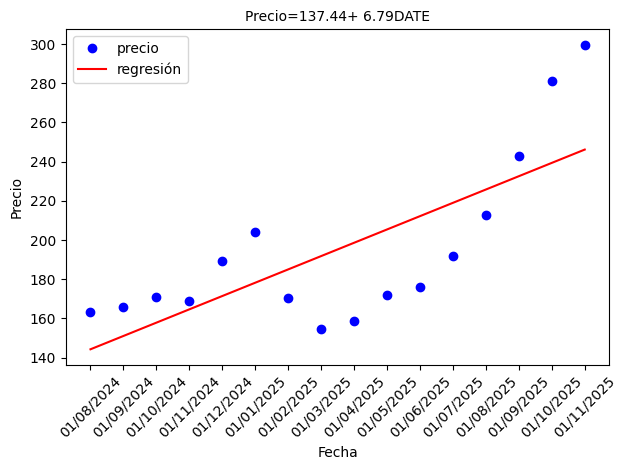

In [ ]:
import matplotlib.pyplot as plt

#plt.figure(figsize=(10,6))
plt.plot('Fecha','Precio',data=N_Google,color='b',marker='o',linestyle='',label='precio')
plt.plot(N_Google['Fecha'],model.fittedvalues,color='red',linestyle='-',label='regresión')
plt.ylabel ('Precio')
plt.xlabel ('Fecha')
#   titulo
plt.title(f'Precio={Beta0:.2f}+ {Beta1:.2f}DATE', size=10)
plt.savefig('Regresion1.jpg')

plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()


plt.show()

In [ ]:
#   Grafica de Regresion Explicacion Residuales
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Beta0 = Coef_reg[0]
Beta1 = Coef_reg[1]
alpha=0.05

days=np.arange(0, 14)
yhat=Beta0+Beta1*days

#plt.figure(figsize=(10,6))
plt.plot(N_Google['Fecha'], N_Google['Precio'], color='b', marker='o', linestyle='', label='precio')
plt.scatter(days, yhat, color='red', linestyle='-', label='estimador')
plt.plot(N_Google['Fecha'], yhat, color='red', linestyle='-', label='regresión')
plt.plot([days,days], [N_Google['Precio'], yhat], color='y', linestyle='--', linewidth=1)


plt.ylabel('Precio')
plt.xlabel('Fecha')
#   titulo
plt.title(f'Precio={Beta0:.2f}+ {Beta1:.2f}Día', size=14)
plt.savefig('Regresion1.jpg')

plt.xticks(rotation=90)
plt.tight_layout()
plt.legend()
#     texto H0
plt.text(10.8,246, r'{',c='k',fontsize=54)
plt.text(10.2,250, r'$U_i$',c='k',fontsize=20)
#plt.text(10.1,177, r'}',c='k',fontsize=21)
#plt.text(10.6,177, r'$U_{i-1}$',c='k',fontsize=12)

plt.show()

In [ ]:
!apt-get install pandoc


In [ ]:
!jupyter nbconvert --to latex /content/Intro_OLS_00.ipynb
